In [9]:
import pandas as pd

dir = "H:/GD_awekimm/[YU]/[Research]/24_JWKIM/국민환경의식/국민환경의식/"

# 2024 국민환경의식조사 원자료 불러오기 & sheet 이름이 "원자료"인 시트 불러오기


df = pd.read_excel(dir+"Data/2024 국민환경의식조사/2024 국민환경의식 설문조사_원자료.xlsx", sheet_name="원자료") 

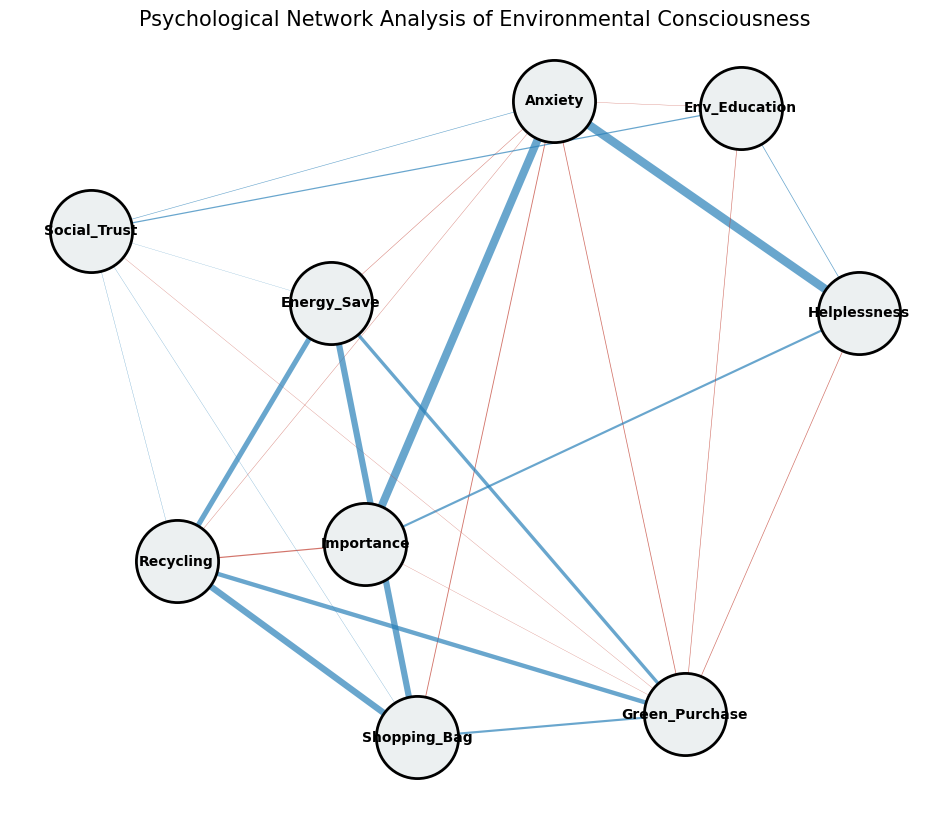

강도 중심성(Node Strength):
Anxiety: 1.0000
Green_Purchase: 1.0000
Social_Trust: 0.7500
Recycling: 0.7500
Energy_Save: 0.6250
Shopping_Bag: 0.6250
Helplessness: 0.5000
Importance: 0.5000
Env_Education: 0.5000


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV

# 2. 분석용 노드(문항) 정의
node_map = {
    'A14_1': 'Anxiety',           # 기후 불안
    'A14_3': 'Helplessness',      # 무력감
    'A11': 'Importance',          # 문제 중요성 인식
    'B6_7': 'Social_Trust',       # 사회적 신뢰
    'C9': 'Env_Education',        # 환경 교육 경험
    'B4_1': 'Energy_Save',        # 절전 실천
    'B4_6': 'Green_Purchase',     # 친환경 구매
    'B4_12': 'Shopping_Bag',      # 장바구니 사용
    'B4_14': 'Recycling'          # 분리배출
}

# 3. 데이터 전처리
data = df[list(node_map.keys())].copy()
data['C9'] = data['C9'].map({1: 1, 2: 0}) # 교육 유무 이분화
data = data.dropna() # 결측치 제거

# 4. 정규화 및 Graphical LASSO 모델 학습
scaler = StandardScaler()
X = scaler.fit_transform(data)

# GraphicalLassoCV는 EBIC와 유사하게 최적의 규제 파라미터를 교차검증으로 찾습니다.
model = GraphicalLassoCV(cv=5)
model.fit(X)

# 5. 정밀 행렬(Precision Matrix)로부터 부분 상관 행렬 계산
precision = model.precision_
d = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(d, d)
np.fill_diagonal(partial_corr, 1.0)

# 6. NetworkX를 이용한 시각화
G = nx.Graph()
nodes = list(node_map.values())

for i, node in enumerate(nodes):
    G.add_node(node)

# 엣지 추가 (부분 상관계수 0.01 이상만 연결)
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        weight = partial_corr[i, j]
        if abs(weight) > 0.01:
            G.add_edge(nodes[i], nodes[j], weight=weight)

# 그래프 레이아웃 및 그리기
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=1.2, seed=42)

edges = G.edges(data=True)
edge_colors = ['#2980b9' if d['weight'] > 0 else '#c0392b' for u, v, d in edges]
edge_widths = [abs(d['weight']) * 15 for u, v, d in edges] # 상관계수 크기에 따른 굵기

nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#ecf0f1', edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, width=edge_widths, alpha=0.7)

plt.title("Psychological Network Analysis of Environmental Consciousness", fontsize=15)
plt.axis('off')
plt.show()

# 7. 중심성(Centrality) 지표 출력
centrality = nx.degree_centrality(G)
print("강도 중심성(Node Strength):")
for node, val in sorted(centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"{node}: {val:.4f}")

In [ ]:

library(readxl)
library(dplyr)

read_excel("../Data/2018 국민환경의식조사/2018 국민환경 의식조사_원자료.xls",
           sheet="원자료") %>% mutate(year=2018) 
read_excel("../Data/2019 국민환경의식조사/2019 국민환경 의식조사_원자료.xls",
                   sheet="2019 국민환경의식 설문조사") %>% mutate(year=2019)
read_excel("../Data/2020 국민환경의식조사/2020 국민환경의식조사_원자료.xls",
           sheet="2020 국민환경의식조사_원자료") %>% mutate(year=2020)
read_excel("../Data/2021 국민환경의식조사/2021_국민환경의식조사_원자료.xls",
           sheet="원자료") %>% mutate(year=2021)
read_excel("../Data/2022 국민환경의식조사/2022_국민환경의식조사_원자료.xlsx",
           sheet="2022 국민환경의식 설문조사_원자료(1028)") %>% mutate(year=2022)
read_excel("../Data/2023 국민환경의식조사/2023_국민환경의식조사_원자료.xlsx",
           sheet="원자료") %>% mutate(year=2023)
dat <- read_excel("../Data/2024 국민환경의식조사/2024 국민환경의식 설문조사_원자료.xlsx",
           sheet="원자료") %>% mutate(year=2024)

dat %>% head

"불안 --> 회복 탄력성 --> 행동"
- 가설 1: 기후 불안은 환경 보호 행동에 양(+)의 영향을 미치지만, 일정 수준을 넘어서면 무력감으로 인해 음(-)의 영향(역 U자형)을 미칠 것이다.
- 가설 2: 환경 교육 경험이나 공동체 참여 의지(회복탄력성)가 높을수록, 불안이 행동으로 전환되는 확률이 높아질 것이다. (moderating effect)
- 가설 3: 위 관계는 연령(MZ세대 vs 기성세대) 및 소득 수준에 따라 유의미하게 다를 것이다. 

names(dat)
anx <- dat %>% select(A14_1:A14_8)
mod <- dat %>% select(C4_1:C4_5,C9)
act <- dat %>% select(B4_1:B4_14)



dat$pid %>% unique %>% length

